# Capacity-limited evidence accumulation: an information-bottleneck account

**Overview and shared theory.** This is the first of five notebooks:

0. **`00_overview.ipynb`** (this one) — general theory shared by every task, read first; a cross-task synthesis at the end, best read last, after 01-04.
1. `01_beads.ipynb` — a volatile source, discrete evidence, a stabilizing (non-absorbing) bound.
2. `02_triangles.ipynb` — the same volatile-source structure, continuous evidence.
3. `03_ddm.ipynb` — a stationary source, an absorbing decision bound (the standard drift-diffusion model).
4. `04_interrogation.ipynb` — the same stationary accumulator as (3), but the *experimenter*, not the accumulator, decides when evidence stops.

Each task notebook has the same three-part shape: **foundations** (the exact derivation for that task's structure), **single-decision dynamics** (what the capacity-limited process looks like moment to moment, on one trial, compared to the normative process on the same evidence), and **testable predictions** (concrete, checkable claims — some already derivable from what's in the notebook, some left as open placeholders).

**The thesis, stated once up front.** An observer who can only retain a limited amount of information about the evidence does not end up with a *noisier* version of the normative belief. It ends up with a **quantized** one: a small number of discrete states, updated by jumps rather than drift. This holds across all four task structures above, though *how* the discreteness is derived differs by task — §1-2 below derive it for the two volatile-source tasks (Parts 1-2 IB, an interval-partition-of-the-posterior argument); `03_ddm.ipynb` and `04_interrogation.ipynb` derive an analogous result for the two stationary-source tasks by a different route (occupancy × relevance, dynamic programming) — noted explicitly in §"What's shared, what differs" below so the parallel isn't overstated.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import matplotlib.pyplot as plt

from ib_core import hmm_window, collapse, ba, beta_critical_binary
from intuitions import glaze_trajectory, glaze_psi

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
# Minimum 12pt for all figure text (titles, labels, ticks, legends), per project convention.
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 13,
})

# Shared color conventions, used identically in every notebook in this series.
NORM_COLOR = "#2b6cb0"   # normative / full capacity
LADDER_COLORS = {2: "#c53030", 4: "#dd6b20", 8: "#d69e2e"}   # capacity-limited, low -> high k
SHADE_COLOR = "#ebf4ff"  # true hidden state

## Part A — Shared theory

### What is `R`, and what form does it take?

`R` is the observer's internal representation — whatever compressed summary of the evidence it retains. The information-bottleneck (IB) optimization places almost no constraint on `R` going in: it could be continuous, discrete, high-dimensional, or any other form. What determines its form is entirely the optimization itself, subject to one thing: `R` must predict a target `Y` (which jar, which triangle, which side is correct) while paying a cost for how much information it carries about the evidence `X`.

For finite `X`, a classical result from convex geometry (Carathéodory's theorem) guarantees that any point on the IB frontier achievable by some continuous `R` is also achievable by a discrete `R` with at most `|X|` states — restricting to discrete `R` loses nothing. The Blahut-Arimoto algorithm (`ib_core.ba`, used throughout this notebook and `01_beads.ipynb`/`02_triangles.ipynb`) exploits this directly: it optimizes over a `k x |X|` matrix of assignment probabilities `p(r|x)`, treating the state count `k` as free and letting the data decide how many states are worth having.

### The representation depends on the evidence only through the posterior

A classical IB result states that the optimal encoder depends on `x` only through `q(x) = p(Y=1|x)`, the posterior over the target. This is checkable directly and exactly: for the beads task, an exact hidden-Markov-model (HMM) forward recursion (`ib_core.hmm_window`, no reference to any particular accumulator model) gives the true posterior for every possible window of evidence, and the Glaze normative recursion (`intuitions.glaze_trajectory`) is compared against it below.

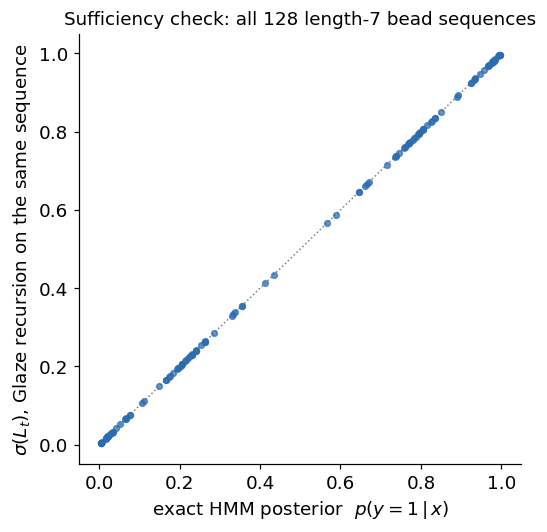

Maximum deviation: 2.22e-16 -- the Glaze recursion is an exact online
implementation of the HMM forward algorithm, so any IB encoder built on top of it has
no channel to the stimulus beyond q(x), the posterior over the current jar.


In [2]:
h = 0.01
w = hmm_window(W=7, h=h, target="filter")   # exact HMM posterior, current jar

# Glaze recursion, run independently on the same 128 length-7 sequences
sig_glaze = np.empty(len(w["seqs"]))
for i, seq in enumerate(w["seqs"]):
    llr_seq = w["llr"][list(seq)]
    L_final = glaze_trajectory(llr_seq, h)[-1]
    sig_glaze[i] = 1 / (1 + np.exp(-L_final))

max_dev = np.max(np.abs(sig_glaze - w["pyx"][:, 1]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1, zorder=0)
ax.scatter(w["pyx"][:, 1], sig_glaze, s=14, color=NORM_COLOR, alpha=0.7)
ax.set_xlabel("exact HMM posterior  $p(y=1\\,|\\,x)$")
ax.set_ylabel(r"$\sigma(L_t)$, Glaze recursion on the same sequence")
ax.set_title(f"Sufficiency check: all {len(w['seqs'])} length-7 bead sequences")
fig.tight_layout()
plt.show()

print(f"Maximum deviation: {max_dev:.2e} -- the Glaze recursion is an exact online")
print("implementation of the HMM forward algorithm, so any IB encoder built on top of it has")
print("no channel to the stimulus beyond q(x), the posterior over the current jar.")

### Why the optimal `R` is discrete rather than a blurred continuous variable

The intuitive default is that a capacity limit should make the belief *noisy* — the same graded, continuous confidence, only corrupted. That is not what the optimization produces, for a geometric reason worth seeing directly rather than taking on faith.

At any stationary point of the IB objective, state `r`'s assignment score for an observation with posterior `q(x)` is `-beta * D_KL[p(y|x) || p(y|r)]`. Expanding the KL divergence for binary `Y` and dropping the term that doesn't depend on `r` (it's the same additive constant for every state, so it can't change which state wins) leaves a quantity that is **affine in `q`**, with slope set by state `r`'s own decoder log-odds `logit(q_r)`. The winning state at each `q` is whichever line is highest there — the **upper envelope** of a set of straight lines. An upper envelope of straight lines necessarily partitions the axis into contiguous intervals ordered by slope: a line cannot win at two separated regions of `q` without crossing above every other line twice, which a straight line cannot do. This is a proof by geometry, not an empirical regularity — the interval-partition structure is forced by the algebra of KL divergence applied to a binary target, for *any* task whose target is binary (beads, triangles, and the two-alternative DDM/interrogation choice all qualify).

beta=9.0: 24 non-negligible states, 4 distinct decoder values: [0.031 0.214 0.786 0.969]


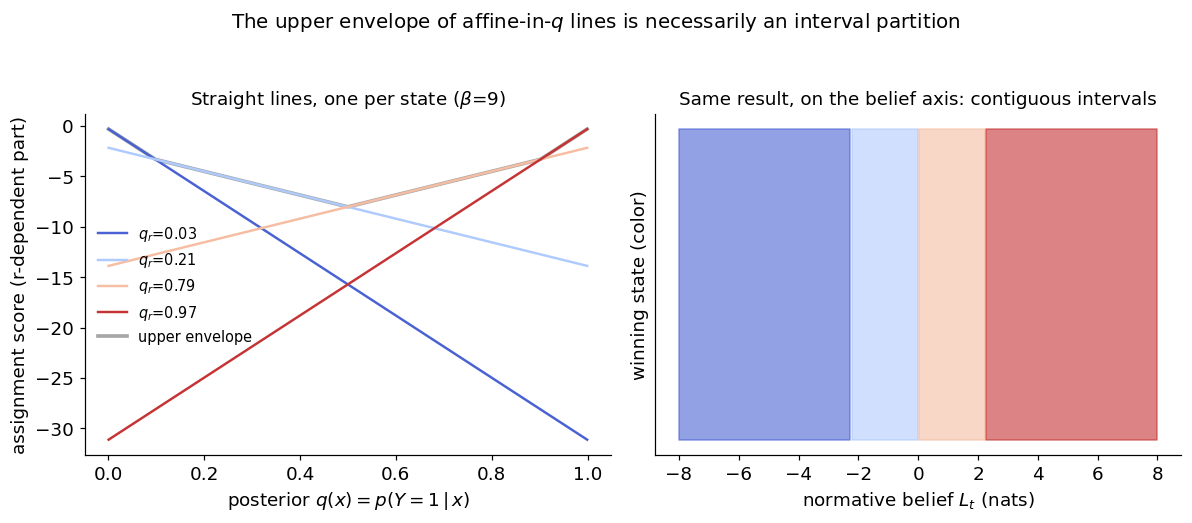

Every state wins on exactly one contiguous stretch of q (equivalently, of L) -- not because
the optimizer was told to produce intervals, but because a straight line cannot re-win a
region it has already lost to another straight line. This is why the capacity-limited belief
is a category, not a blur: the full derivation and staircase frontier are in 01_beads.ipynb.


In [3]:
pxc, pyc, _ = collapse(w["px"], w["pyx"])
beta_demo = 9.0
res = ba(pxc, pyc, beta=beta_demo)

# Keep only states with non-negligible occupancy, and their distinct decoder values.
keep = res["pr"] > 1e-3
q_states = np.unique(np.round(res["pyr"][keep, 1], 6))
print(f"beta={beta_demo}: {keep.sum()} non-negligible states, {len(q_states)} distinct decoder values: "
      f"{np.round(q_states, 3)}")

q_grid = np.linspace(1e-3, 1 - 1e-3, 400)
line_colors = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(q_states)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
envelope = np.full_like(q_grid, -np.inf)
winner = np.zeros_like(q_grid, dtype=int)
for j, qr in enumerate(q_states):
    line = beta_demo * (q_grid * np.log(qr) + (1 - q_grid) * np.log(1 - qr))
    ax.plot(q_grid, line, color=line_colors[j], lw=1.6, label=f"$q_r$={qr:.2f}")
    better = line > envelope
    envelope = np.where(better, line, envelope)
    winner = np.where(better, j, winner)
ax.plot(q_grid, envelope, color="black", lw=2.4, alpha=0.35, label="upper envelope", zorder=0)
ax.set_xlabel(r"posterior $q(x) = p(Y{=}1\,|\,x)$")
ax.set_ylabel("assignment score (r-dependent part)")
ax.set_title(f"Straight lines, one per state ($\\beta$={beta_demo:g})")
ax.legend(frameon=False, fontsize=9.5, loc="center left")

ax2 = axes[1]
L_grid = np.linspace(-8, 8, 400)
q_of_L = 1 / (1 + np.exp(-L_grid))
winner_by_L = np.array([winner[np.argmin(np.abs(q_grid - q))] for q in q_of_L])
for j in range(len(q_states)):
    mask = winner_by_L == j
    ax2.fill_between(L_grid, 0, 1, where=mask, color=line_colors[j], alpha=0.6, step="mid")
ax2.set_xlabel(r"normative belief $L_t$ (nats)")
ax2.set_ylabel("winning state (color)")
ax2.set_title("Same result, on the belief axis: contiguous intervals")
ax2.set_yticks([])
fig.suptitle("The upper envelope of affine-in-$q$ lines is necessarily an interval partition", y=1.03)
fig.tight_layout()
plt.show()

print("Every state wins on exactly one contiguous stretch of q (equivalently, of L) -- not because")
print("the optimizer was told to produce intervals, but because a straight line cannot re-win a")
print("region it has already lost to another straight line. This is why the capacity-limited belief")
print("is a category, not a blur: the full derivation and staircase frontier are in 01_beads.ipynb.")

### Reconciling this with the classical "add noise to the posterior" result

| | variable that is noisy | what `R` looks like |
|---|---|---|
| Intuitive "blur" model | `L_t` itself | continuous, smeared belief |
| IB "add noise" result | assignment `r` given `q(x)` | discrete state; stochastic only at boundaries |

The classical result correctly says `R` is a noisy function of `q(x)`. The noise lives in the **assignment to `R`**, not in `q(x)` itself: given a posterior value, the observer does not deterministically land in one state — there is residual randomness about which state gets assigned, concentrated near the boundaries between states (visible above as the soft, not-yet-vertical crossings between lines at finite `beta`; §2.1 of `01_beads.ipynb` shows these sharpen into hard thresholds as capacity grows). This is categorically different from adding noise to `L_t` itself, which would smear the belief value. The two framings describe the same fixed point of the same equation, viewed differently — but they make different behavioral predictions: the blur model predicts graded confidence varying smoothly with `L_t`; the IB model predicts categorical confidence with a sharp (if noisy) criterion, and what varies with capacity is *how sharp* that criterion is, not how graded the belief is.

### Glossary

| symbol | name | units | meaning |
|---|---|---|---|
| `h` | hazard rate | -- | probability the source switches between observations (beads, triangles) |
| `d'` | discriminability | -- | signal-to-noise of one observation (triangles; the continuous analog of the bead task's `p`) |
| `L_t` | belief | nats | log posterior odds; the Glaze decision variable (beads, triangles) |
| `X` | evidence | -- | the observation sequence, or equivalently the belief |
| `Y` | target | -- | the current source (beads, triangles) or the correct side (DDM, interrogation) |
| `R` | representation | -- | the observer's internal state |
| `I(X;R)` | **capacity** | bits | what the observer retains about the evidence |
| `I(R;Y)` | **predictiveness** | bits | what that buys in knowledge of `Y` |
| `I(X;Y)` | evidence ceiling | bits | the most any observer could achieve |
| `beta` | trade-off | -- | price paid per bit of capacity |
| `beta_c` | critical `beta` | -- | below it, the optimum ignores the evidence entirely |
| `k` | states | -- | number of distinguishable values `R` takes |
| `v` | drift | -- | evidence strength/direction (DDM, interrogation) |
| `s` | noise | -- | diffusion noise (DDM, interrogation) |
| `a` | bound separation | -- | distance between the two decision bounds (DDM) |
| `z_frac` | starting point | -- | fraction of `a` where accumulation starts (DDM, interrogation) |
| `T` | viewing duration | -- | experimenter-controlled evidence duration (interrogation) |

**Shared conventions across every figure in this series:** blue = the normative process (no capacity limit); warm colors (red -> orange -> yellow) = capacity-limited processes, from the most severe limit to the mildest; light shading = the true hidden state, so belief can be compared to ground truth directly; dotted gray lines = a reference criterion or bound.

### What's shared, what differs: methods across the four tasks

All four tasks solve the same optimization — maximize predictiveness `I(R;Y)` at a fixed capacity `I(X;R)` — but the concrete machinery differs because the underlying process differs (volatile + stabilizing bound vs. stationary + absorbing/reflecting bound):

- **Beads, triangles** (volatile source, non-absorbing bound): solved two ways that are checked against each other. One-shot: enumerate observation windows exactly (`ib_core.hmm_window`) and run Blahut-Arimoto (`ib_core.ba`) swept over `beta` — used above and throughout `01_beads.ipynb`/`02_triangles.ipynb`. Recursive: search directly over finite-state machines (`ib_core.optimal_recursive_fsm`, exhaustive for small `k`, hill-climbed beyond that) — used for the single-trial "bounded ladder" dynamics in both task notebooks.
- **DDM** (stationary source, absorbing bound): no windowed enumeration is possible (the process doesn't return to a fixed set of states). Instead, an exact fine-grid reference chain gives occupancy and relevance in closed form, and dynamic programming (`ib_optimal_placement.optimal_partition`) finds the exact globally-optimal placement of `k` non-uniform nodes along the evidence axis — derived in full in `03_ddm.ipynb`.
- **Interrogation** (stationary source, no bound at all): the same DP machinery as the DDM, but occupancy is a closed-form Gaussian mixture over the task's viewing-duration distribution rather than a fundamental-matrix calculation, since there's no absorption to read it off — derived in `04_interrogation.ipynb`.

Both routes arrive at the same qualitative answer — a small number of states, placed non-uniformly, updated by discrete jumps — but the DDM/interrogation route does not go through the Blahut-Arimoto/interval-partition argument above at all. Treat the geometric argument in this section as specific to the two volatile-source tasks; the absorbing/reflecting tasks get their own, independently-derived version of "why not blur" in their own foundations sections.

---

## Part B — Synthesis across all four tasks

*(Best read after `01_beads.ipynb` – `04_interrogation.ipynb`; the claims below depend on results derived in each.)*

| | beads (`01_beads`) | triangles (`02_triangles`) | DDM (`03_ddm`) | interrogation (`04_interrogation`) |
|---|---|---|---|---|
| source | volatile (switches forever) | volatile (switches forever) | stationary (fixed per trial) | stationary (fixed per trial) |
| bound | stabilizing, non-absorbing | stabilizing, non-absorbing | absorbing (bound = decision) | none (reflecting; readout timed externally) |
| evidence | discrete (bead color) | continuous (star position) | continuous | continuous |
| task structure | one SNR, one `h` | blockwise SNR and `h` | one SNR; asymmetric prior; mixed SNR | one SNR; experimenter-timed, near-flat-hazard viewing duration |
| capacity-limited process | solved `k`-state machine (`get_optimal_fsm`) — usually `+-1` steps, bigger corrective jumps once `h` is large | same search, finer alphabet — jump size can also depend on evidence *magnitude* | non-uniform absorbing chain, node placement solved from the actual drift | non-uniform reflecting chain, same node-placement machinery minus the absorbing ends |

Across all four, the same picture holds up: a capacity limit does not smear the evidence-accumulation process into a fuzzier version of itself. It **coarsens the trajectory into a staircase** — a small number of discrete states, connected by small, bounded jumps (usually one rung, more at the extremes once switching is fast enough to matter — see `01_beads`'s jump-size table — or position-dependent for the DDM), that follows the same qualitative path as the normative process but can only ever be *at* one of a few places. Five consequences followed directly from watching this unfold in time rather than only in aggregate:

1. **At the most severe limit, memory itself disappears.** The beads `k=2` machine (`01_beads`) and the DDM's coarsest chains (`03_ddm`) both degrade toward using only the most recent evidence, not a noisier integral of all of it.
2. **The same discrete "mental model" produces different-looking dynamics depending on what it's handed** — a block's difficulty and hazard (`02_triangles`), or a trial's match to the observer's prior or its individual difficulty (`03_ddm`, §3.2-3.3) — even though the representation's *structure* doesn't change. This is a distinct, separately testable signature from "capacity changes the ceiling": it says a fixed-capacity observer's trial-to-trial variability is not (only) noise, but a predictable consequence of running one fixed, coarse structure over trials that differ. `03_ddm` §3.2-3.3 also showed this cost is almost entirely a *dynamics* effect, not an *accuracy* one — getting the prior or the difficulty-mix wrong barely moves pooled accuracy at any capacity.
3. **The representation itself must be solved for, not guessed.** A fixed, hazard-blind rule ("step one rung toward the evidence, always") coincides with the true optimum at low hazard, but loses up to 40% of the achievable predictive information once switching is fast enough to matter (`01_beads`). The real capacity-limited machine adapts its transition rule to the actual hazard rate (bigger corrective jumps from extreme states) and, for continuous evidence, to the actual evidence magnitude (ignoring weak, unconvincing observations at low capacity) — neither of which a fixed rule can reproduce.
4. **Diminishing returns set in fast — except when the task doesn't let them.** In beads, triangles, and the absorbing DDM, 6-8 states (often 3-4 for the DDM) already captured nearly everything a much larger capacity would buy, consistent with `01_beads`'s finding that most predictiveness is available within the first few branches of the IB staircase. `04_interrogation` shows this isn't a universal law of capacity limitation — it's a property of what the task needs the representation to get right. An absorbing bound only ever needs "which side, and roughly when," and a handful of states already nails both; take the bound away and score the accumulator's literal position at an externally-chosen, unpredictable moment instead, and the same machinery needs 3-4x the states (`04_interrogation`) to close the same gap. Fast saturation was never about capacity limits *per se* — it was about how forgiving a terminating decision's low-dimensional summary happens to be.
5. **What looks fine in aggregate can still look wrong trial by trial, and the gap between them is diagnostic, not just a nuisance.** `03_ddm` §3.1 showed this directly for the DDM: a coarse chain can match a terminating decision's accuracy and mean RT almost exactly while its single-trial paths still look nothing like the smooth original, because "accuracy" and "mean RT" are only two low-dimensional summaries of a whole distribution over paths. `04_interrogation`'s task removes the boundary that let the absorbing case get away with that, and the gap closes because the summary being scored (position at a fixed time) stops being forgiving. Whether a given real task's aggregate performance measure is a good proxy for the underlying representation is therefore an empirical question about *that task's* structure, not something that can be assumed from capacity limits alone.